# Health Spending and Life Expectancy

In this notebook we explore how health spending and life expectancy compare across six countries, using the `healthexp` dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

healthexp = sns.load_dataset("healthexp")
healthexp.shape

(274, 4)

## How does health spending compare across countries?

We start by summarising the mean health spending and mean life expectancy for each country across all years in the dataset.

In [2]:
summary = (
    healthexp.groupby("Country")
    .agg(
        mean_spending=("Spending_USD", "mean"),
        mean_life_exp=("Life_Expectancy", "mean")
    )
    .round(1)
    .reset_index()
    .sort_values("mean_spending", ascending=False)
)

summary

,Country,mean_spending,mean_life_exp
5,USA,4388.6,75.8
1,France,3045.1,79.6
0,Canada,2685.8,78.7
2,Germany,2667.3,76.7
3,Great Britain,2034.2,77.6
4,Japan,1860.3,79.6


In [3]:
top_country = summary.iloc[0]["Country"]
top_spending = summary.iloc[0]["mean_spending"]

print(f"The country with the highest average health spending is {top_country}, at ${top_spending} per capita.")

The country with the highest average health spending is USA, at $4388.6 per capita.


## Visualising the comparison

A bar chart makes the differences across countries easier to see than the table alone.

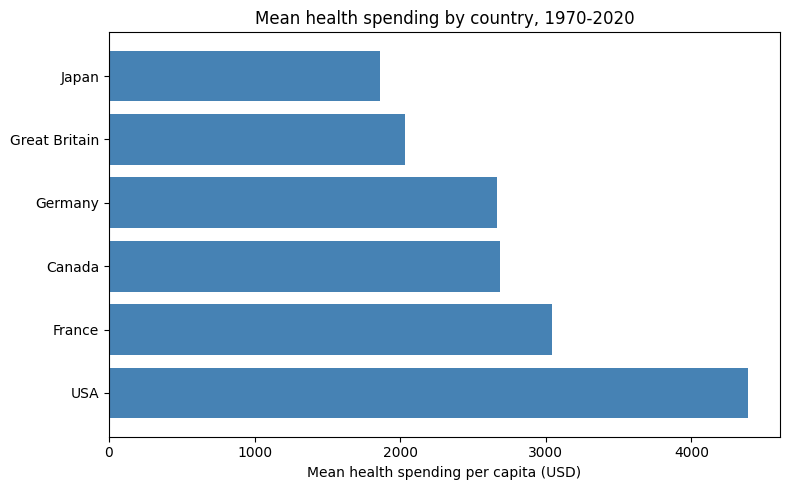

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(summary["Country"], summary["mean_spending"], color="steelblue")

ax.set_xlabel("Mean health spending per capita (USD)")
ax.set_title("Mean health spending by country, 1970-2020")

plt.tight_layout()
plt.show()

## Exporting this notebook

To share this analysis with someone who does not have Python installed, export it to HTML: in Positron, use the notebook toolbar's export option, or run the following from a terminal (this requires installing `nbconvert` first with `pip install nbconvert`, since it isn't one of the packages installed for this course):

```
python -m nbconvert --to html this-notebook.ipynb
```

On a Mac, use `python3` instead of `python`.

The exported HTML file preserves the text, code, and output exactly as they appear here, but it is a static snapshot: cells can no longer be re-run, and the code is no longer connected to a live Python session.